# Simulasi Klasifikasi Penerima Bansos Menggunakan Naive Bayes

Notebook ini adalah simulasi mandiri dengan algoritma Gaussian Naive Bayes menggunakan metodologi CRISP-DM. Dataset, target, encoding kategori, dan pembagian data dibuat konsisten agar hasilnya dapat dibandingkan secara adil dengan algoritma lain.


## 1. Business Understanding (CRISP-DM)

Tujuan penelitian adalah mengklasifikasikan kelayakan penerima bantuan sosial (`Layak` atau `Tidak Layak`) berdasarkan jumlah tanggungan, pendapatan, pekerjaan, kondisi rumah, dan pendidikan. Model menjadi pendukung pengambilan keputusan, bukan penentu tunggal.


In [1]:
# Library dasar untuk membaca data, mengolah dataset, visualisasi, pemodelan, dan evaluasi.
import json
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB


In [2]:
# Konfigurasi utama penelitian.
DATASET_PATH = Path('Data_Penduduk.xlsx')
OUTPUT_DIR = Path('outputs_naive_bayes')
OUTPUT_DIR.mkdir(exist_ok=True)
TARGET_COLUMN = 'Status_Kelayakan'
TARGET_ENCODED_COLUMN = 'Status_Kelayakan_Kode'
RAW_FEATURE_COLUMNS = ['Jumlah_Tanggungan', 'Pendapatan', 'Pekerjaan', 'Kondisi_Rumah', 'Pendidikan']
FEATURE_COLUMNS = ['Jumlah_Tanggungan', 'Pendapatan', 'Pekerjaan_Kode', 'Kondisi_Rumah_Kode', 'Pendidikan_Kode']
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_SPLITS = 6
print('Dataset tersedia:', DATASET_PATH.exists())
print('Path dataset:', DATASET_PATH)


Dataset tersedia: True
Path dataset: Data_Penduduk.xlsx


## 2. Data Understanding (CRISP-DM)

Dataset dimuat dari Excel tanpa mengubah data sumber. Tahap ini memeriksa struktur, kualitas, dan distribusi kelas data.


In [3]:
# Membaca dataset dari file Excel.
df_raw = pd.read_excel(DATASET_PATH)
print('Jumlah baris dan kolom:', df_raw.shape)
df_raw.head()


Jumlah baris dan kolom: (598, 11)


,Nomor,NIK,Nama,JK,Hub_Kel,Pendidikan,Pekerjaan,Jumlah_Tanggungan,Pendapatan,Kondisi_Rumah,Status_Kelayakan
0,1,3602191001720003,AJUM,L,Kepala Keluarga,SD,Petani/Pekebun,1,<500.000,Kurang Layak,Layak
1,2,3602192608980002,ABDUL FATAH,L,Kepala Keluarga,SLTA/Sederajat,BURUH HARIAN LEPAS,1,500.000,Kurang Layak,Layak
2,3,3602190503700004,SUGANA,L,Kepala Keluarga,SD,Petani/Pekebun,1,500.000,Sederhana,Layak
3,4,3602190103750004,SAMIN,L,Kepala Keluarga,SD,Petani/Pekebun,1,500.000-1.000.000,Kurang Layak,Layak
4,5,3602190401710001,MAMAN,L,Kepala Keluarga,SD,Wiraswasta,2,2.000.000-4.000.000,Sederhana,Tidak Layak


### Pemeriksaan Kualitas dan Karakteristik Data

Tahap ini memeriksa struktur data, tipe data, missing value, duplikat, statistik deskriptif, serta distribusi kelas target.


In [4]:
# Informasi tipe data dan jumlah data non-null.
print('Informasi dataset:')
df_raw.info()


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Nomor              598 non-null    int64
 1   NIK                598 non-null    int64
 2   Nama               598 non-null    str  
 3   JK                 598 non-null    str  
 4   Hub_Kel            598 non-null    str  
 5   Pendidikan         598 non-null    str  
 6   Pekerjaan          598 non-null    str  
 7   Jumlah_Tanggungan  598 non-null    int64
 8   Pendapatan         598 non-null    str  
 9   Kondisi_Rumah      598 non-null    str  
 10  Status_Kelayakan   598 non-null    str  
dtypes: int64(3), str(8)
memory usage: 51.5 KB


In [5]:
# Pengecekan missing value dan duplikat pada dataset awal.
print('Jumlah missing value per kolom:')
print(df_raw.isna().sum())

print('\nJumlah data duplikat:', df_raw.duplicated().sum())


Jumlah missing value per kolom:
Nomor                0
NIK                  0
Nama                 0
JK                   0
Hub_Kel              0
Pendidikan           0
Pekerjaan            0
Jumlah_Tanggungan    0
Pendapatan           0
Kondisi_Rumah        0
Status_Kelayakan     0
dtype: int64

Jumlah data duplikat: 0


In [6]:
# Statistik deskriptif kolom numerik.
numeric_columns = df_raw.select_dtypes(include='number').columns.tolist()
print('Kolom numerik:', numeric_columns)

if numeric_columns:
    display(df_raw[numeric_columns].describe())
else:
    print('Belum ada kolom numerik pada dataset awal.')


Kolom numerik: ['Nomor', 'NIK', 'Jumlah_Tanggungan']


,Nomor,NIK,Jumlah_Tanggungan
count,598.000000,5.980000e+02,598.000000
mean,299.500000,3.602192e+15,1.831104
std,172.772008,1.611950e+09,1.151753
min,1.000000,3.602190e+15,0.000000
25%,150.250000,3.602191e+15,1.000000
50%,299.500000,3.602192e+15,2.000000
75%,448.750000,3.602192e+15,3.000000
max,598.000000,3.602197e+15,6.000000


Distribusi label awal:
Status_Kelayakan
Layak          300
Tidak Layak    298
Name: count, dtype: int64


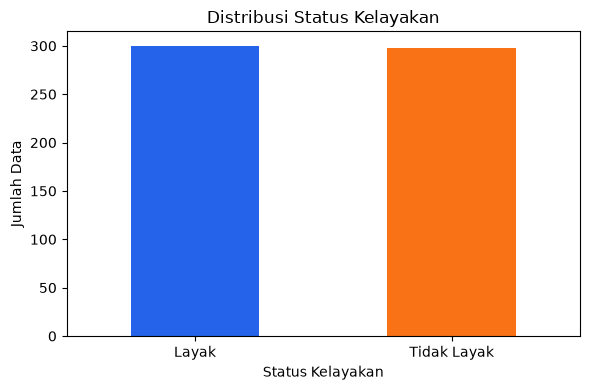

In [7]:
# Distribusi kelas target awal.
print('Distribusi label awal:')
print(df_raw[TARGET_COLUMN].value_counts(dropna=False))

label_counts = df_raw[TARGET_COLUMN].value_counts(dropna=False)
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['#2563eb', '#f97316'])
plt.title('Distribusi Status Kelayakan')
plt.xlabel('Status Kelayakan')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Data Preparation (CRISP-DM)

Tahap ini meliputi pembersihan data, standarisasi kategori, validasi kualitas data, pemilihan fitur, ordinal encoding, dan pembagian data. Gaussian Naive Bayes tidak membutuhkan normalisasi Min-Max karena menghitung parameter distribusi Gaussian dari nilai fitur setiap kelas.


In [8]:
# Fungsi pembersihan dan penyeragaman data.
def clean_text(value):
    if pd.isna(value):
        return value
    return str(value).strip()


def normalize_label(value):
    value = clean_text(value)
    mapping = {
        'Tidal Layak': 'Tidak Layak',
        'tidal layak': 'Tidak Layak',
        'tidak layak': 'Tidak Layak',
        'layak': 'Layak',
    }
    return mapping.get(value, value)


def normalize_pekerjaan(value):
    value = clean_text(value)
    mapping = {
        'BURUH HARIAN LEPAS': 'Buruh Harian Lepas',
        'Buruh Harian Lepas': 'Buruh Harian Lepas',
        'Buruh Harian': 'Buruh Harian Lepas',
        'PETANI/PEKEBUN': 'Petani/Pekebun',
        'Petani': 'Petani/Pekebun',
        'Buruh Tani/Perkebunan': 'Buruh Tani',
        'GURU': 'Guru',
        'Guru Honorer': 'Karyawan Honorer',
        'Ibu Rumah Tangga': 'Mengurus Rumah Tangga',
        'Belum/Tidak Bekerja': 'Tidak Bekerja',
        'Pelajar/Mahasiswa': 'Tidak Bekerja',
        'Tentara Nasional Indonesia': 'TNI',
        'Ustadz/Mubaligh': 'Ustadz',
        'Pensiunan': 'Pensiunan',
        'Pensiunan PNS': 'Pensiunan',
        'Pegawai Negeri Sipil': 'PNS',
        'Pedagang Kecil': 'Pedagang',
        'Karyawan': 'Karyawan Swasta',
        'Ojek': 'Wiraswasta',
        'Penjahit': 'Wiraswasta',
        'wiraswasta': 'Wiraswasta',
    }
    return mapping.get(value, value)


def normalize_pendidikan(value):
    value = clean_text(value)
    mapping = {
        'Tamat SLTP/Sederajat': 'SLTP/Sederajat',
        'Tamat SLTA/Sederajat': 'SLTA/Sederajat',
        'STRATA 1 / D IV': 'D4',
    }
    return mapping.get(value, value)


def pendapatan_to_numeric(value):
    value = clean_text(value)
    mapping = {
        '<500.000': 400000,
        '500.000': 500000,
        '500.000-1.000.000': 750000,
        '1.000.000-2.000.000': 1500000,
        '2.000.000-4.000.000': 3000000,
        '>4.000.000': 4500000,
    }
    if value in mapping:
        return mapping[value]

    cleaned = value.replace('Rp', '').replace(' ', '').replace('.', '').replace(',', '.')
    try:
        return float(cleaned)
    except ValueError as exc:
        raise ValueError(f'Format pendapatan tidak dikenal: {value}') from exc


In [9]:
# Cleaning data tanpa mengubah dataset asli.
df = df_raw.copy()
print('Jumlah data sebelum cleaning:', df.shape)

text_columns = ['Pendidikan', 'Pekerjaan', 'Kondisi_Rumah', TARGET_COLUMN]
for column in text_columns:
    df[column] = df[column].apply(clean_text)

df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(normalize_label)
df['Pekerjaan'] = df['Pekerjaan'].apply(normalize_pekerjaan)
df['Pendidikan'] = df['Pendidikan'].apply(normalize_pendidikan)
df['Pendapatan'] = df['Pendapatan'].apply(pendapatan_to_numeric)
df['Jumlah_Tanggungan'] = pd.to_numeric(df['Jumlah_Tanggungan'], errors='coerce')

print('Jumlah data setelah cleaning:', df.shape)
df.head()


Jumlah data sebelum cleaning: (598, 11)
Jumlah data setelah cleaning: (598, 11)


,Nomor,NIK,Nama,JK,Hub_Kel,Pendidikan,Pekerjaan,Jumlah_Tanggungan,Pendapatan,Kondisi_Rumah,Status_Kelayakan
0,1,3602191001720003,AJUM,L,Kepala Keluarga,SD,Petani/Pekebun,1,400000,Kurang Layak,Layak
1,2,3602192608980002,ABDUL FATAH,L,Kepala Keluarga,SLTA/Sederajat,Buruh Harian Lepas,1,500000,Kurang Layak,Layak
2,3,3602190503700004,SUGANA,L,Kepala Keluarga,SD,Petani/Pekebun,1,500000,Sederhana,Layak
3,4,3602190103750004,SAMIN,L,Kepala Keluarga,SD,Petani/Pekebun,1,750000,Kurang Layak,Layak
4,5,3602190401710001,MAMAN,L,Kepala Keluarga,SD,Wiraswasta,2,3000000,Sederhana,Tidak Layak


In [10]:
# Validasi missing value setelah cleaning.
missing_values = df.isna().sum()
print('Missing value setelah cleaning:')
print(missing_values)

if missing_values.sum() == 0:
    print('\nDataset tidak memiliki missing value.')
else:
    print('\nDataset masih memiliki missing value dan baris tersebut tidak digunakan pada pemodelan.')


Missing value setelah cleaning:
Nomor                0
NIK                  0
Nama                 0
JK                   0
Hub_Kel              0
Pendidikan           0
Pekerjaan            0
Jumlah_Tanggungan    0
Pendapatan           0
Kondisi_Rumah        0
Status_Kelayakan     0
dtype: int64

Dataset tidak memiliki missing value.


In [11]:
# Validasi data duplikat.
duplicates_before = df_raw.duplicated().sum()
duplicates_after = df.duplicated().sum()

print('Jumlah data duplikat sebelum cleaning:', duplicates_before)
print('Jumlah data duplikat setelah cleaning :', duplicates_after)


Jumlah data duplikat sebelum cleaning: 0
Jumlah data duplikat setelah cleaning : 0


In [12]:
# Validasi tipe data dan kategori setelah cleaning.
print('Tipe data setelah cleaning:')
print(df.dtypes)

for column in ['Pendidikan', 'Pekerjaan', 'Kondisi_Rumah', TARGET_COLUMN]:
    print(f'\nKategori {column}:')
    print(df[column].value_counts().sort_index())


Tipe data setelah cleaning:
Nomor                int64
NIK                  int64
Nama                   str
JK                     str
Hub_Kel                str
Pendidikan             str
Pekerjaan              str
Jumlah_Tanggungan    int64
Pendapatan           int64
Kondisi_Rumah          str
Status_Kelayakan       str
dtype: object

Kategori Pendidikan:
Pendidikan
D2                  3
D3                  1
D4                 17
SD                333
SLTA/Sederajat     71
SLTP/Sederajat     72
Tidak Sekolah     101
Name: count, dtype: int64

Kategori Pekerjaan:
Pekerjaan
Buruh Harian Lepas        16
Buruh Tani                 2
Guru                       7
Karyawan Honorer           2
Karyawan Swasta            8
Mengurus Rumah Tangga     53
PNS                        4
Pedagang                   2
Pensiunan                  3
Perangkat Desa             2
Perawat                    1
Perdagangan                5
Petani/Pekebun           261
TNI                        1
Tidak Beker

### Visualisasi Distribusi Fitur Utama

Visualisasi ini digunakan untuk melihat sebaran atribut utama setelah proses cleaning, sehingga karakteristik data yang digunakan dalam pemodelan dapat lebih mudah dipahami.


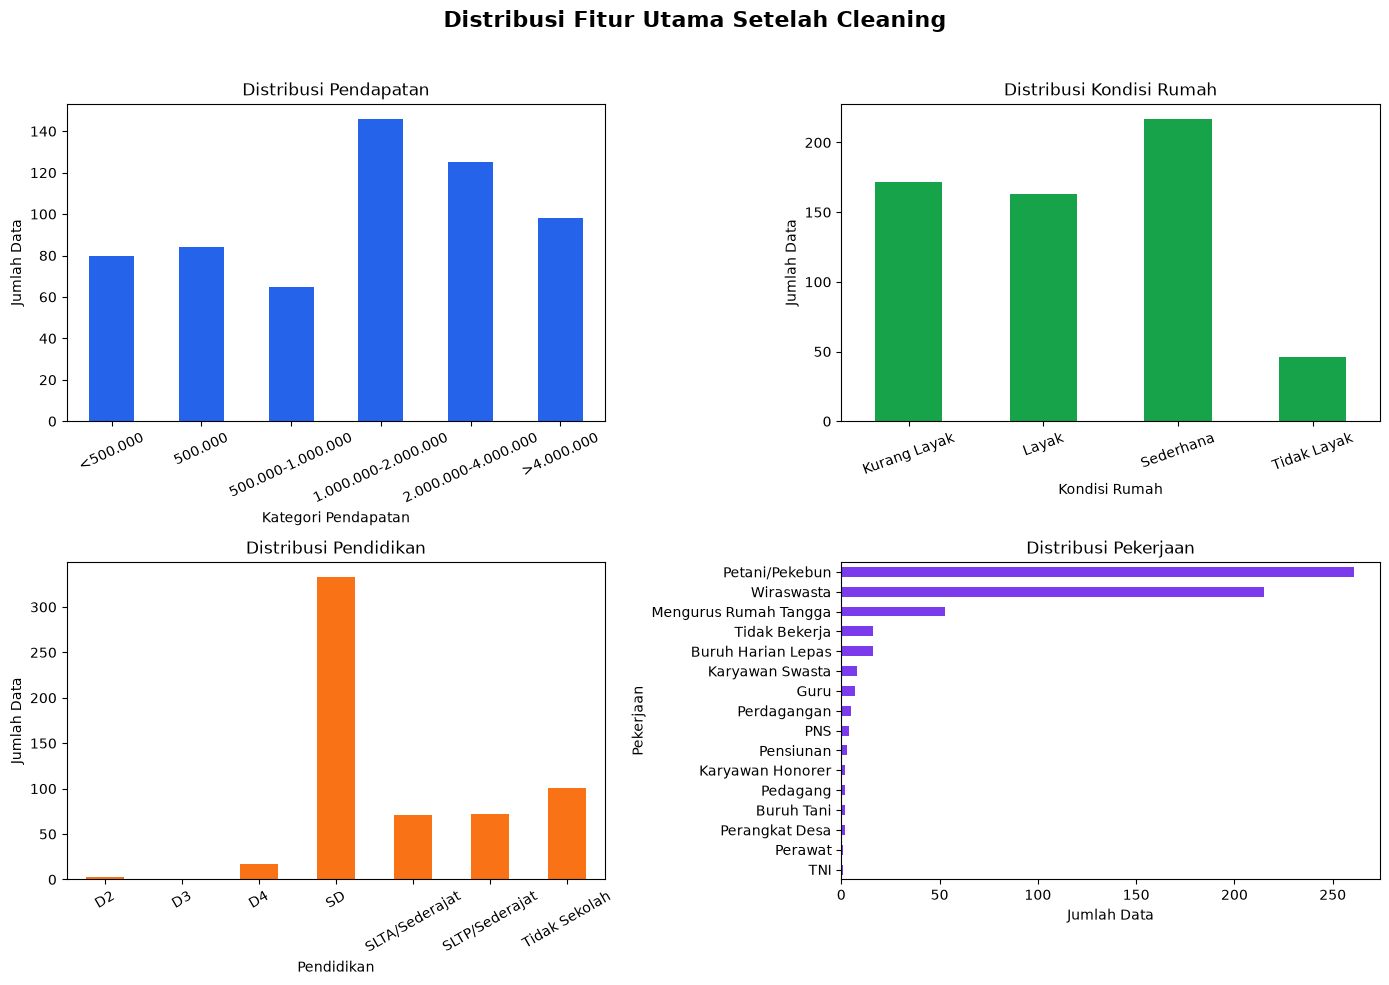

In [13]:
# Visualisasi distribusi fitur utama setelah cleaning.
def pendapatan_category_from_numeric(value):
    value = float(value)
    if value < 500000:
        return '<500.000'
    if value == 500000:
        return '500.000'
    if value <= 1000000:
        return '500.000-1.000.000'
    if value <= 2000000:
        return '1.000.000-2.000.000'
    if value <= 4000000:
        return '2.000.000-4.000.000'
    return '>4.000.000'


pendapatan_order = [
    '<500.000',
    '500.000',
    '500.000-1.000.000',
    '1.000.000-2.000.000',
    '2.000.000-4.000.000',
    '>4.000.000',
]

df_visual = df.copy()
df_visual['Pendapatan_Kategori'] = df_visual['Pendapatan'].apply(pendapatan_category_from_numeric)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Fitur Utama Setelah Cleaning', fontsize=16, fontweight='bold')

df_visual['Pendapatan_Kategori'].value_counts().reindex(pendapatan_order, fill_value=0).plot(
    kind='bar', ax=axes[0, 0], color='#2563eb'
)
axes[0, 0].set_title('Distribusi Pendapatan')
axes[0, 0].set_xlabel('Kategori Pendapatan')
axes[0, 0].set_ylabel('Jumlah Data')
axes[0, 0].tick_params(axis='x', rotation=25)

df_visual['Kondisi_Rumah'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 1], color='#16a34a'
)
axes[0, 1].set_title('Distribusi Kondisi Rumah')
axes[0, 1].set_xlabel('Kondisi Rumah')
axes[0, 1].set_ylabel('Jumlah Data')
axes[0, 1].tick_params(axis='x', rotation=20)

df_visual['Pendidikan'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1, 0], color='#f97316'
)
axes[1, 0].set_title('Distribusi Pendidikan')
axes[1, 0].set_xlabel('Pendidikan')
axes[1, 0].set_ylabel('Jumlah Data')
axes[1, 0].tick_params(axis='x', rotation=30)

df_visual['Pekerjaan'].value_counts().sort_values().plot(
    kind='barh', ax=axes[1, 1], color='#7c3aed'
)
axes[1, 1].set_title('Distribusi Pekerjaan')
axes[1, 1].set_xlabel('Jumlah Data')
axes[1, 1].set_ylabel('Pekerjaan')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [14]:
# Feature selection sesuai variabel penelitian.
selected_columns = ['NIK', 'Nama'] + RAW_FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in selected_columns if column not in df.columns]

if missing_columns:
    raise KeyError(f'Kolom yang dibutuhkan belum tersedia di dataframe: {missing_columns}')

df_selected = df[selected_columns].dropna().copy()

print('Fitur yang digunakan:', RAW_FEATURE_COLUMNS)
print('Target:', TARGET_COLUMN)
print('Jumlah data setelah feature selection:', df_selected.shape)
df_selected.head()


Fitur yang digunakan: ['Jumlah_Tanggungan', 'Pendapatan', 'Pekerjaan', 'Kondisi_Rumah', 'Pendidikan']
Target: Status_Kelayakan
Jumlah data setelah feature selection: (598, 8)


,NIK,Nama,Jumlah_Tanggungan,Pendapatan,Pekerjaan,Kondisi_Rumah,Pendidikan,Status_Kelayakan
0,3602191001720003,AJUM,1,400000,Petani/Pekebun,Kurang Layak,SD,Layak
1,3602192608980002,ABDUL FATAH,1,500000,Buruh Harian Lepas,Kurang Layak,SLTA/Sederajat,Layak
2,3602190503700004,SUGANA,1,500000,Petani/Pekebun,Sederhana,SD,Layak
3,3602190103750004,SAMIN,1,750000,Petani/Pekebun,Kurang Layak,SD,Layak
4,3602190401710001,MAMAN,2,3000000,Wiraswasta,Sederhana,SD,Tidak Layak


### Data Encoding

Fitur kategorikal dan target dikonversi dengan ordinal encoding sesuai mapping yang ditetapkan. One-Hot Encoding tidak digunakan.


In [15]:
# Mapping kategori yang digunakan pada Ordinal Encoding.
PEKERJAAN_KODE_MAP = {
    'Tidak Bekerja': 1,
    'Mengurus Rumah Tangga': 1,
    'Buruh Harian Lepas': 2,
    'Buruh Tani': 2,
    'Petani/Pekebun': 3,
    'Ustadz': 3,
    'Pedagang': 3,
    'Perdagangan': 4,
    'Wiraswasta': 4,
    'Karyawan Honorer': 4,
    'Karyawan Swasta': 5,
    'Perangkat Desa': 5,
    'Perawat': 6,
    'Guru': 6,
    'Pensiunan': 6,
    'PNS': 7,
    'TNI': 7,
}

KONDISI_RUMAH_KODE_MAP = {
    'Tidak Layak': 1,
    'Kurang Layak': 2,
    'Sederhana': 3,
    'Layak': 4,
}

PENDIDIKAN_KODE_MAP = {
    'Tidak Sekolah': 1,
    'SD': 2,
    'SLTP/Sederajat': 3,
    'SLTA/Sederajat': 4,
    'D1': 5,
    'D2': 6,
    'D3': 7,
    'D4': 8,
    'S1': 9,
    'S2': 10,
    'S3': 11,
}

STATUS_KELAYAKAN_KODE_MAP = {
    'Layak': 1,
    'Tidak Layak': 0,
}

STATUS_KELAYAKAN_LABEL_MAP = {value: key for key, value in STATUS_KELAYAKAN_KODE_MAP.items()}


def encode_with_mapping(value, mapping, column_name):
    value = clean_text(value)
    if value not in mapping:
        raise ValueError(f'Kategori {column_name} tidak ditemukan pada mapping: {value}')
    return mapping[value]


In [16]:
# Proses Ordinal Encoding.
df_model = df_selected.copy()

df_model['Pekerjaan_Kode'] = df_model['Pekerjaan'].apply(
    lambda value: encode_with_mapping(value, PEKERJAAN_KODE_MAP, 'Pekerjaan')
)
df_model['Kondisi_Rumah_Kode'] = df_model['Kondisi_Rumah'].apply(
    lambda value: encode_with_mapping(value, KONDISI_RUMAH_KODE_MAP, 'Kondisi_Rumah')
)
df_model['Pendidikan_Kode'] = df_model['Pendidikan'].apply(
    lambda value: encode_with_mapping(value, PENDIDIKAN_KODE_MAP, 'Pendidikan')
)
df_model[TARGET_ENCODED_COLUMN] = df_model[TARGET_COLUMN].apply(
    lambda value: encode_with_mapping(value, STATUS_KELAYAKAN_KODE_MAP, TARGET_COLUMN)
)

df_model = df_model[FEATURE_COLUMNS + [TARGET_COLUMN, TARGET_ENCODED_COLUMN]].dropna().copy()
print('Contoh data setelah encoding:')
df_model.head(10)


Contoh data setelah encoding:


,Jumlah_Tanggungan,Pendapatan,Pekerjaan_Kode,Kondisi_Rumah_Kode,Pendidikan_Kode,Status_Kelayakan,Status_Kelayakan_Kode
0,1,400000,3,2,2,Layak,1
1,1,500000,2,2,4,Layak,1
2,1,500000,3,3,2,Layak,1
3,1,750000,3,2,2,Layak,1
4,2,3000000,4,3,2,Tidak Layak,0
5,2,500000,3,2,2,Layak,1
6,1,3000000,1,4,2,Tidak Layak,0
7,2,500000,3,2,1,Layak,1
8,4,1500000,4,2,2,Layak,1
9,2,750000,3,2,3,Layak,1


## 4. Modelling (CRISP-DM): Pembagian Data

Data dibagi secara stratified menjadi 80% training dan 20% testing. Data testing disimpan untuk evaluasi akhir; cross-validation hanya dilakukan pada data training agar tidak terjadi kebocoran data.


In [17]:
# Memisahkan fitur dan target sebelum pembagian data.
X = df_model[FEATURE_COLUMNS].copy()
y = df_model[TARGET_ENCODED_COLUMN].copy()

print('Shape fitur:', X.shape)
print('Shape target:', y.shape)
print('\nContoh fitur sebelum normalisasi:')
X.head()


Shape fitur: (598, 5)
Shape target: (598,)

Contoh fitur sebelum normalisasi:


,Jumlah_Tanggungan,Pendapatan,Pekerjaan_Kode,Kondisi_Rumah_Kode,Pendidikan_Kode
0,1,400000,3,2,2
1,1,500000,2,2,4
2,1,500000,3,3,2
3,1,750000,3,2,2
4,2,3000000,4,3,2


In [18]:
# Split utama: data train dan test dengan stratify agar proporsi kelas tetap seimbang.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print('Jumlah data training:', len(X_train_raw))
print('Jumlah data testing:', len(X_test_raw))
print('\nDistribusi label training:')
print(y_train.map(STATUS_KELAYAKAN_LABEL_MAP).value_counts())
print('\nDistribusi label testing:')
print(y_test.map(STATUS_KELAYAKAN_LABEL_MAP).value_counts())


Jumlah data training: 478
Jumlah data testing: 120

Distribusi label training:
Status_Kelayakan_Kode
Layak          240
Tidak Layak    238
Name: count, dtype: int64

Distribusi label testing:
Status_Kelayakan_Kode
Tidak Layak    60
Layak          60
Name: count, dtype: int64


### Visualisasi Distribusi Kelas Setelah Split


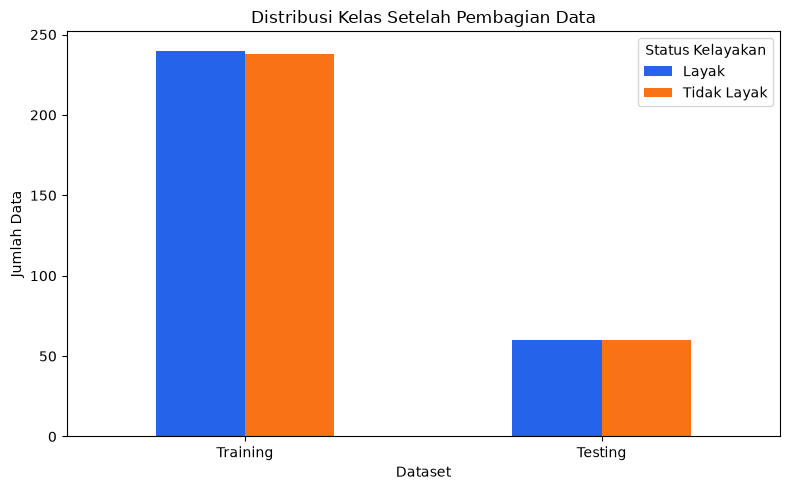

In [19]:
split_distribution = pd.DataFrame({'Training': y_train.map(STATUS_KELAYAKAN_LABEL_MAP).value_counts(), 'Testing': y_test.map(STATUS_KELAYAKAN_LABEL_MAP).value_counts()}).reindex(['Layak', 'Tidak Layak'])
ax = split_distribution.T.plot(kind='bar', figsize=(8, 5), color=['#2563eb', '#f97316'])
ax.set_title('Distribusi Kelas Setelah Pembagian Data')
ax.set_xlabel('Dataset')
ax.set_ylabel('Jumlah Data')
ax.legend(title='Status Kelayakan')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Data Training dan Testing untuk Naive Bayes

Gaussian Naive Bayes menggunakan fitur hasil encoding secara langsung. Tidak ada normalisasi Min-Max maupun pemilihan nilai K karena keduanya bukan bagian dari algoritma Naive Bayes.


In [20]:
# Naive Bayes memakai fitur hasil encoding secara langsung.
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()
print('Contoh data training untuk Naive Bayes:')
X_train.head()


Contoh data training untuk Naive Bayes:


,Jumlah_Tanggungan,Pendapatan,Pekerjaan_Kode,Kondisi_Rumah_Kode,Pendidikan_Kode
528,1,4500000,4,4,3
385,0,750000,3,2,1
125,0,1500000,5,3,4
366,0,500000,3,3,2
485,0,3000000,1,3,1


In [21]:
print('Statistik data training untuk Naive Bayes:')
display(X_train.describe().round(4))


Statistik data training untuk Naive Bayes:


,Jumlah_Tanggungan,Pendapatan,Pekerjaan_Kode,Kondisi_Rumah_Kode,Pendidikan_Kode
count,478.0000,4.780000e+02,478.0000,478.0000,478.0000
mean,1.7992,1.915690e+06,3.2490,2.8138,2.3954
std,1.1297,1.446736e+06,1.0983,0.9139,1.3461
min,0.0000,4.000000e+05,1.0000,1.0000,1.0000
25%,1.0000,5.000000e+05,3.0000,2.0000,2.0000
50%,2.0000,1.500000e+06,3.0000,3.0000,2.0000
75%,3.0000,3.000000e+06,4.0000,4.0000,3.0000
max,6.0000,4.500000e+06,7.0000,4.0000,8.0000


### Pelatihan dan Validasi Gaussian Naive Bayes

Gaussian Naive Bayes menghitung probabilitas kelas berdasarkan fitur numerik dengan asumsi independensi kondisional antarfitur. Kelas prediksi dipilih dari probabilitas posterior terbesar: `P(Kelas | Fitur) ∝ P(Kelas) × P(Fitur | Kelas)`. Kinerja model divalidasi menggunakan Stratified 5-Fold Cross-Validation pada data training.


In [22]:
# Konfigurasi Stratified 5-Fold Cross-Validation.
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro', 'f1_macro': 'f1_macro'}

# Setiap fold melatih GaussianNB baru pada k-1 fold dan memvalidasi pada fold tersisa.
cv_results = cross_validate(GaussianNB(), X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
cv_results_df = pd.DataFrame({
    'Fold': range(1, CV_SPLITS + 1),
    'Accuracy': cv_results['test_accuracy'],
    'Precision Macro': cv_results['test_precision_macro'],
    'Recall Macro': cv_results['test_recall_macro'],
    'F1-Score Macro': cv_results['test_f1_macro'],
})
print('Hasil Stratified 5-Fold Cross-Validation:')
cv_results_df.round(4)


Hasil Stratified 5-Fold Cross-Validation:


,Fold,Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,1,0.8500,0.8846,0.8500,0.8465
1,2,0.8500,0.8846,0.8500,0.8465
2,3,0.8750,0.9000,0.8750,0.8730
3,4,0.9000,0.9167,0.9000,0.8990
4,5,0.8861,0.9082,0.8846,0.8842
5,6,0.8734,0.9000,0.8718,0.8709


In [23]:
# Ringkasan rata-rata dan standar deviasi hasil cross-validation.
cv_summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1-Score Macro'],
    'Rata-rata': cv_results_df[['Accuracy', 'Precision Macro', 'Recall Macro', 'F1-Score Macro']].mean().values,
    'Standar Deviasi': cv_results_df[['Accuracy', 'Precision Macro', 'Recall Macro', 'F1-Score Macro']].std(ddof=1).values,
})
print('Ringkasan Cross-Validation:')
cv_summary_df.round(4)


Ringkasan Cross-Validation:


,Metric,Rata-rata,Standar Deviasi
0,Accuracy,0.8724,0.0198
1,Precision Macro,0.8990,0.0127
2,Recall Macro,0.8719,0.0196
3,F1-Score Macro,0.8700,0.0207


## 5. Evaluation (CRISP-DM): Evaluasi Akhir pada Data Testing

Setelah cross-validation, Gaussian Naive Bayes dilatih pada seluruh data training dan dievaluasi satu kali pada data testing 20% yang belum pernah digunakan.


In [24]:
# Pelatihan final pada seluruh data training dan prediksi pada data test.
def build_naive_bayes_model():
    return GaussianNB()

model_naive_bayes = build_naive_bayes_model()
model_naive_bayes.fit(X_train, y_train)
y_pred_best = model_naive_bayes.predict(X_test)
prediction_preview = pd.DataFrame({
    'Aktual': y_test.map(STATUS_KELAYAKAN_LABEL_MAP).values,
    'Prediksi': pd.Series(y_pred_best).map(STATUS_KELAYAKAN_LABEL_MAP).values,
})
prediction_preview.head(10)


,Aktual,Prediksi
0,Tidak Layak,Tidak Layak
1,Tidak Layak,Layak
2,Layak,Layak
3,Layak,Layak
4,Layak,Layak
5,Layak,Layak
6,Tidak Layak,Tidak Layak
7,Layak,Layak
8,Layak,Layak
9,Layak,Layak


### Prediksi Data Testing

Berikut adalah contoh perbandingan label aktual dan prediksi model pada data testing.


In [25]:
prediction_preview.head(10)


,Aktual,Prediksi
0,Tidak Layak,Tidak Layak
1,Tidak Layak,Layak
2,Layak,Layak
3,Layak,Layak
4,Layak,Layak
5,Layak,Layak
6,Tidak Layak,Tidak Layak
7,Layak,Layak
8,Layak,Layak
9,Layak,Layak


### Metrik Evaluasi dan Confusion Matrix

Seluruh metrik pada bagian ini dihitung dari data testing yang tidak digunakan saat cross-validation maupun pelatihan model.


In [26]:
# Metrik evaluasi model terbaik pada data test.
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred_best, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred_best, average='macro', zero_division=0)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1],
})
metrics_df


,Metric,Score
0,Accuracy,0.883333
1,Precision,0.905405
2,Recall,0.883333
3,F1-Score,0.881723


In [27]:
# Confusion Matrix.
cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=['Aktual Tidak Layak', 'Aktual Layak'],
    columns=['Prediksi Tidak Layak', 'Prediksi Layak'],
)
cm_df


,Prediksi Tidak Layak,Prediksi Layak
Aktual Tidak Layak,46,14
Aktual Layak,0,60


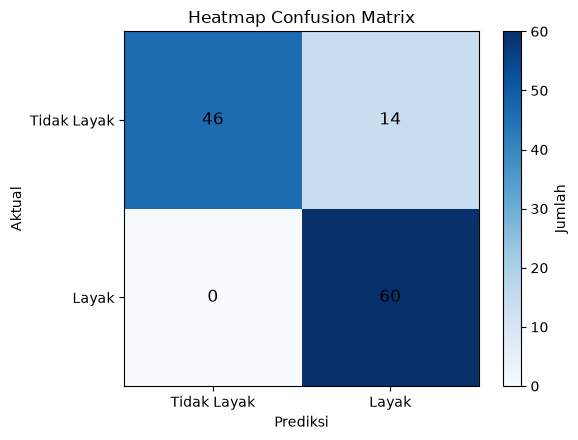

In [28]:
# Heatmap Confusion Matrix.
plt.figure(figsize=(6, 4.5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Heatmap Confusion Matrix')
plt.colorbar(label='Jumlah')
plt.xticks([0, 1], ['Tidak Layak', 'Layak'])
plt.yticks([0, 1], ['Tidak Layak', 'Layak'])

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        plt.text(col, row, cm[row, col], ha='center', va='center', color='black', fontsize=12)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()


In [29]:
# Classification Report dan ringkasan metrik.
print('Classification Report:')
print(classification_report(
    y_test,
    y_pred_best,
    labels=[0, 1],
    target_names=['Tidak Layak', 'Layak'],
    zero_division=0,
))

print('Accuracy :', accuracy)
print('Precision:', precision)
print('Recall   :', recall)
print('F1-Score :', f1)


Classification Report:
              precision    recall  f1-score   support

 Tidak Layak       1.00      0.77      0.87        60
       Layak       0.81      1.00      0.90        60

    accuracy                           0.88       120
   macro avg       0.91      0.88      0.88       120
weighted avg       0.91      0.88      0.88       120

Accuracy : 0.8833333333333333
Precision: 0.9054054054054055
Recall   : 0.8833333333333333
F1-Score : 0.8817234581807942


## 6. Deployment (CRISP-DM)

Setelah evaluasi, model Gaussian Naive Bayes dilatih ulang pada seluruh data hasil encoding untuk deployment. Artefak dan hasil disimpan di folder `outputs_naive_bayes`.


In [30]:
# Model final dilatih ulang dengan seluruh data hasil encoding untuk kebutuhan deployment.
X_all_features = X.copy()
final_model = build_naive_bayes_model()
final_model.fit(X_all_features, y)
model_path = OUTPUT_DIR / 'model_naive_bayes_bansos.joblib'
metadata_path = OUTPUT_DIR / 'model_naive_bayes_metadata.json'
evaluation_path = OUTPUT_DIR / 'evaluasi_naive_bayes.csv'
cross_validation_path = OUTPUT_DIR / 'cross_validation_naive_bayes.csv'
joblib.dump(final_model, model_path)
pd.DataFrame({'Metric': ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1-Score Macro'], 'Score': [accuracy, precision, recall, f1]}).to_csv(evaluation_path, index=False)
cv_results_df.to_csv(cross_validation_path, index=False)
metadata = {'algorithm': 'GaussianNB', 'features': FEATURE_COLUMNS, 'normalization': 'Tidak digunakan (GaussianNB memakai fitur hasil encoding)', 'cross_validation': 'StratifiedKFold 5-fold pada data training', 'cv_splits': CV_SPLITS, 'test_size': TEST_SIZE, 'random_state': RANDOM_STATE, 'accuracy_test': float(accuracy), 'precision_macro_test': float(precision), 'recall_macro_test': float(recall), 'f1_macro_test': float(f1)}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print('Model disimpan ke:', model_path)
print('Metadata disimpan ke:', metadata_path)
print('Evaluasi disimpan ke:', evaluation_path)


Model disimpan ke: outputs_naive_bayes\model_naive_bayes_bansos.joblib
Metadata disimpan ke: outputs_naive_bayes\model_naive_bayes_metadata.json
Evaluasi disimpan ke: outputs_naive_bayes\evaluasi_naive_bayes.csv


In [31]:
# Fungsi prediksi warga baru dengan preprocessing dan encoding yang sama.
def prediksi_warga_baru(pendapatan, jumlah_tanggungan, pendidikan, pekerjaan, kondisi_rumah):
    pendapatan_nilai = pendapatan_to_numeric(pendapatan) if isinstance(pendapatan, str) else pendapatan
    pekerjaan_normal = normalize_pekerjaan(pekerjaan)
    pendidikan_normal = normalize_pendidikan(pendidikan)
    kondisi_rumah_normal = clean_text(kondisi_rumah)

    input_df = pd.DataFrame([{
        'Jumlah_Tanggungan': jumlah_tanggungan,
        'Pendapatan': pendapatan_nilai,
        'Pekerjaan_Kode': encode_with_mapping(pekerjaan_normal, PEKERJAAN_KODE_MAP, 'Pekerjaan'),
        'Kondisi_Rumah_Kode': encode_with_mapping(kondisi_rumah_normal, KONDISI_RUMAH_KODE_MAP, 'Kondisi_Rumah'),
        'Pendidikan_Kode': encode_with_mapping(pendidikan_normal, PENDIDIKAN_KODE_MAP, 'Pendidikan'),
    }], columns=FEATURE_COLUMNS)

    prediksi_kode = int(final_model.predict(input_df)[0])
    prediksi_label = STATUS_KELAYAKAN_LABEL_MAP[prediksi_kode]
    proba = final_model.predict_proba(input_df)[0]
    probabilitas = {
        STATUS_KELAYAKAN_LABEL_MAP[int(kode)]: float(nilai)
        for kode, nilai in zip(final_model.classes_, proba)
    }
    return prediksi_label, probabilitas


In [32]:
# Contoh prediksi warga baru.
status, proba = prediksi_warga_baru(
    pendapatan='500.000-1.000.000',
    jumlah_tanggungan=3,
    pendidikan='SD',
    pekerjaan='Buruh Tani',
    kondisi_rumah='Kurang Layak',
)

print('Hasil prediksi:', status)
print('Probabilitas:', proba)


Hasil prediksi: Layak
Probabilitas: {'Tidak Layak': 0.05535202604886879, 'Layak': 0.9446479739511311}


In [33]:
df_hasil = df.copy()
df_hasil.loc[df_model.index, 'Prediksi_Kelayakan_Kode'] = final_model.predict(X_all_features)
df_hasil['Prediksi_Kelayakan'] = df_hasil['Prediksi_Kelayakan_Kode'].map(STATUS_KELAYAKAN_LABEL_MAP)
hasil_path = OUTPUT_DIR / 'hasil_prediksi_penduduk_naive_bayes.xlsx'
export_df = df_hasil[['NIK', 'Nama', 'Prediksi_Kelayakan']].copy()
export_df.columns = ['NIK', 'Nama', 'Status_Kelayakan']
export_df['NIK'] = export_df['NIK'].astype(str)
export_df.to_excel(hasil_path, index=False)
print('Hasil prediksi semua data disimpan ke:', hasil_path)
export_df.head()


Hasil prediksi semua data disimpan ke: outputs_naive_bayes\hasil_prediksi_penduduk_naive_bayes.xlsx


,NIK,Nama,Status_Kelayakan
0,3602191001720003,AJUM,Layak
1,3602192608980002,ABDUL FATAH,Layak
2,3602190503700004,SUGANA,Layak
3,3602190103750004,SAMIN,Layak
4,3602190401710001,MAMAN,Tidak Layak
